# M2 baseline: linear VAR, and why COVID must be modeled (not dropped)

This notebook walks through the long-window (2001--2024) pseudo-real-time
results and makes one methodological point precisely:

1. A plain VAR with iterated multi-step forecasts **blows up through COVID** — post-2020 fits can forecast unemployment near 100%.
2. Dropping COVID origins is dishonest: it discards exactly the stress episode the paper is about.
3. The fix is a **COVID dummy with a first-lag interaction** (`models/covid_dummy_var.py`): the dummy absorbs the 2020--21 outlier in-sample, and because the future dummy is zero, forecasts revert to tranquil-time dynamics. This restores sane full-sample forecasts.

We then run the honest full-sample horse race (hard vs hard+UMCSENT) and apply the Giacomini--White conditional predictive ability test.

All inputs are loaded from disk (parquet forecasts + cached pickle for VIX); no FRED calls, so this runs offline.

In [1]:
import warnings
warnings.simplefilter('ignore')

import sys, pickle
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from evaluation.gw import gw_test

ROOT = Path.cwd().parent
vanilla = pd.read_parquet(ROOT / 'data/forecasts/long_window_linear_var.parquet')
dummy   = pd.read_parquet(ROOT / 'data/forecasts/long_window_covid_dummy.parquet')

# VIX (monthly mean) from the cached inputs — no FRED call.
with open(ROOT / 'data/cache/inputs.pkl', 'rb') as f:
    static = pickle.load(f)['static']
vix_m = static['VIXCLS'].copy()
vix_m.index = pd.to_datetime(vix_m.index)
vix_m = vix_m.resample('MS').mean()

# Well-known NBER recession windows in our sample (hardcoded to avoid FRED).
BANDS = [
    (pd.Timestamp('2001-03-01'), pd.Timestamp('2001-11-01')),
    (pd.Timestamp('2007-12-01'), pd.Timestamp('2009-06-01')),
    (pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-01')),
]
print(f'vanilla: {len(vanilla):,} rows | dummy: {len(dummy):,} rows')
print(f'origins {dummy.origin.min().date()} .. {dummy.origin.max().date()}')

vanilla: 9,216 rows | dummy: 9,216 rows
origins 2001-01-01 .. 2024-12-01


## 1. The COVID blow-up, and the dummy fix

Unemployment, h=3, plotted as forecast vs realized. The vanilla VAR
produces enormous post-2020 forecasts; the dummy VAR stays sane.

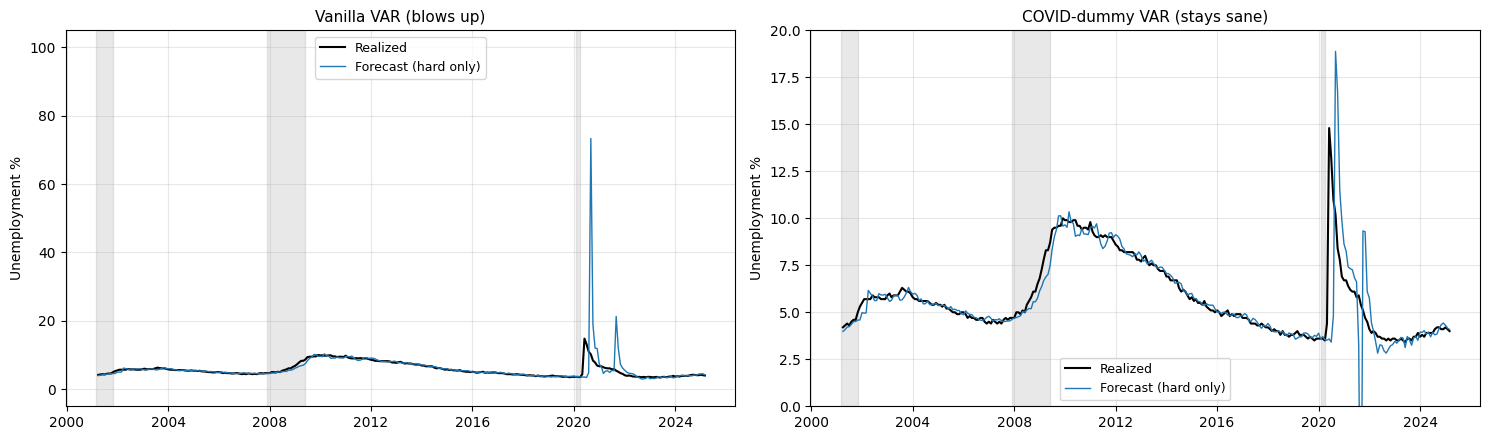

Vanilla UR h=3 max forecast: 73.4
Dummy   UR h=3 max forecast: 18.9


In [2]:
def ur3(res):
    s = res[(res.target=='unemployment') & (res.horizon==3) & res.ok].copy()
    s['eval_date'] = s['origin'] + pd.DateOffset(months=3)
    return s[s.spec=='hard_only'].set_index('eval_date')

v, d = ur3(vanilla), ur3(dummy)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=False)
for ax, frame, title in [(axes[0], v, 'Vanilla VAR (blows up)'),
                          (axes[1], d, 'COVID-dummy VAR (stays sane)')]:
    ax.plot(frame.index, frame['realized'], color='black', lw=1.5, label='Realized')
    ax.plot(frame.index, frame['forecast'], color='#1f77b4', lw=1.0, label='Forecast (hard only)')
    for s_, e_ in BANDS:
        ax.axvspan(s_, e_, color='grey', alpha=0.18)
    ax.set_title(title, fontsize=11); ax.set_ylabel('Unemployment %')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
axes[0].set_ylim(-5, 105)
axes[1].set_ylim(0, 20)
plt.tight_layout(); plt.show()

print('Vanilla UR h=3 max forecast:', round(v['forecast'].max(), 1))
print('Dummy   UR h=3 max forecast:', round(d['forecast'].max(), 1))

## 2. Full-sample RMSE: dummy vs vanilla (hard-only)

How much does the dummy reduce RMSE on the full sample (COVID included)?
Large gains at long horizons confirm the vanilla blow-up was the problem.

In [3]:
def rmse(res, spec):
    s = res[res.spec==spec].dropna(subset=['error']).copy(); s['se'] = s['error']**2
    return s.groupby(['target','horizon'])['se'].mean().pow(0.5)

cmp = pd.DataFrame({'vanilla': rmse(vanilla,'hard_only'),
                    'dummy':   rmse(dummy,'hard_only')})
cmp['dummy_cuts_RMSE_%'] = 100*(cmp['vanilla']-cmp['dummy'])/cmp['vanilla']
print(cmp.round(3).to_string())

                               vanilla  dummy  dummy_cuts_RMSE_%
target                horizon                                   
core_pce              1          0.609  0.595              2.371
                      3          0.983  0.755             23.141
                      6          1.950  0.929             52.382
                      12         3.152  1.235             60.818
industrial_production 1          3.155  2.778             11.955
                      3         10.743  5.408             49.661
                      6         23.336  7.043             69.819
                      12        46.439  8.126             82.502
payrolls              1          2.197  1.455             33.779
                      3          6.575  2.602             60.428
                      6         11.681  3.628             68.936
                      12        23.567  5.416             77.018
unemployment          1          1.371  0.845             38.387
                      3  

## 3. Honest horse race: hard vs hard+UMCSENT (full sample, dummy model)

Now that COVID is modeled rather than excluded, compare hard-only to
hard+UMCSENT on the *full* sample. Positive `UM_imp_%` = UMCSENT helps.

In [4]:
race = pd.DataFrame({'hard': rmse(dummy,'hard_only'),
                     'hard_UM': rmse(dummy,'hard_plus_umcsent')})
race['UM_imp_%'] = 100*(race['hard']-race['hard_UM'])/race['hard']
print(race.round(3).to_string())

                                hard  hard_UM  UM_imp_%
target                horizon                          
core_pce              1        0.595    0.602    -1.255
                      3        0.755    0.767    -1.515
                      6        0.929    0.942    -1.433
                      12       1.235    1.353    -9.565
industrial_production 1        2.778    2.556     7.990
                      3        5.408    4.898     9.420
                      6        7.043    6.816     3.220
                      12       8.126   10.186   -25.348
payrolls              1        1.455    1.425     2.056
                      3        2.602    2.714    -4.297
                      6        3.628    4.290   -18.225
                      12       5.416    8.678   -60.230
unemployment          1        0.845    0.848    -0.393
                      3        1.661    1.637     1.478
                      6        2.592    2.957   -14.081
                      12       4.366    7.127   

UMCSENT alone is a wash-to-slightly-negative on the long window: it helps
industrial production at short horizons (+8–10% at h=1–3) but hurts at
long horizons. A single survey isn't enough — the multi-indicator soft
factor (short window, notebook 03) is where the real gains appear.

## 4. Giacomini–White test: is the soft edge concentrated in stress regimes?

For each (target, horizon), compare hard vs hard+UMCSENT losses with:
- **DM** (unconditional): is one model better *on average*?
- **GW conditional on VIX**: is the *relative* performance predictable from the VIX level at the forecast origin?

A small `GW_vix_p` with a large `DM_p` would say: soft data's edge is regime-specific even when it nets to zero unconditionally.

In [5]:
def gw_panel(res, soft_spec):
    rows = []
    for tgt in ['unemployment','industrial_production','payrolls','core_pce']:
        for h in [1,3,6,12]:
            hard = res[(res.target==tgt)&(res.horizon==h)&(res.spec=='hard_only')].set_index('origin')
            soft = res[(res.target==tgt)&(res.horizon==h)&(res.spec==soft_spec)].set_index('origin')
            idx = hard.index.intersection(soft.index)
            l1 = (hard.loc[idx,'error']**2); l2 = (soft.loc[idx,'error']**2)
            vx = vix_m.reindex(idx)
            ok = l1.notna() & l2.notna() & vx.notna()
            l1,l2,vx = l1[ok].values, l2[ok].values, vx[ok].values
            if len(l1) < 20: continue
            u = gw_test(l1, l2, tau=h, choice='uncond')
            c = gw_test(l1, l2, tau=h, choice='cond', instruments=vx)
            rows.append({'target':tgt,'horizon':h,'n':len(l1),
                         'soft_imp_%': 100*(np.sqrt(l1.mean())-np.sqrt(l2.mean()))/np.sqrt(l1.mean()),
                         'DM_p': u.pval, 'GW_vix_p': c.pval,
                         'better': 'soft' if u.better_model==2 else 'hard'})
    return pd.DataFrame(rows)

gw_long = gw_panel(dummy, 'hard_plus_umcsent')
print(gw_long.round(4).to_string(index=False))

               target  horizon   n  soft_imp_%   DM_p  GW_vix_p better
         unemployment        1 288     -0.3934 0.8080    0.6559   hard
         unemployment        3 288      1.4783 0.7243    0.4561   soft
         unemployment        6 288    -14.0815 0.4824    0.3681   hard
         unemployment       12 287    -63.2576 0.3456    0.3652   hard
industrial_production        1 288      7.9899 0.0790    0.1510   soft
industrial_production        3 288      9.4200 0.4435    0.4495   soft
industrial_production        6 288      3.2202 0.8514    0.5484   soft
industrial_production       12 288    -25.3476 0.4758    0.3896   hard
             payrolls        1 288      2.0559 0.3288    0.4910   soft
             payrolls        3 288     -4.2970 0.5961    0.3562   hard
             payrolls        6 288    -18.2250 0.4374    0.3903   hard
             payrolls       12 288    -60.2298 0.3599    0.3811   hard
             core_pce        1 288     -1.2549 0.3460    0.6242   hard
      

## Takeaways

1. **The COVID dummy is load-bearing.** It cuts full-sample hard-only RMSE by 60–80% at long horizons by removing the iterated-forecast blow-up — without discarding the COVID episode.
2. **UMCSENT alone is not the story** on the long window: small help for IP at short horizons, small harm at long horizons.
3. **No significant GW rejections yet** for UMCSENT: DM and GW-conditional p-values are all comfortably above 0.05. The point estimates lean soft for IP at short horizons, but we cannot reject equal predictive ability. The richer soft factor and the regime-switching models (M4) are where we expect the conditional story to sharpen.

**Next:** notebook 03 — the multi-indicator soft factor on the short window, where the long-horizon real-activity gains are large (UR h=12: +57%).